In [1]:
import sys
sys.path.append("./src")

In [2]:
import os
os.getcwd()

'/Users/lola/Desktop/Agentic_Thesis'

In [3]:
print(os.listdir("src"))

['quality_ctrl.py']


In [4]:
import scanpy as sc
import pandas as pd
import data_load as dl
import quality_ctrl as qc
import preprocessing as pr

In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Load 


In [5]:
pbmc_data = dl.load_pbmc3k()

In [6]:
pbmc_data.var_names_make_unique()

In [7]:
pbmc_data

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


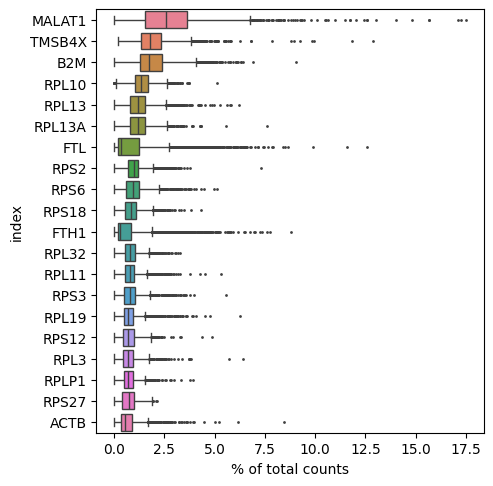

In [8]:
sc.pl.highest_expr_genes(pbmc_data, n_top=20)

In [9]:
pbmc_data = qc.basic_qc(pbmc_data)

## QUALITY CONTROL

Removed bad-quality cells and genes.

+ filtered cells with low genes
+ filtered genes
+ Filtered for acceptable mitochondrial percentage
+ QC metrics

In [10]:
pbmc_data

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

### Quality Control Violin Plots

These violin plots visualize the distribution of key quality control metrics across all cells, including the number of detected genes (**n_genes_by_counts**), total UMI counts (**total_counts**), and the percentage of mitochondrial gene expression (**pct_counts_mt**). The plots are used to identify potential low-quality cells, doublets, or stressed cells and to guide the selection of appropriate filtering thresholds during preprocessing.

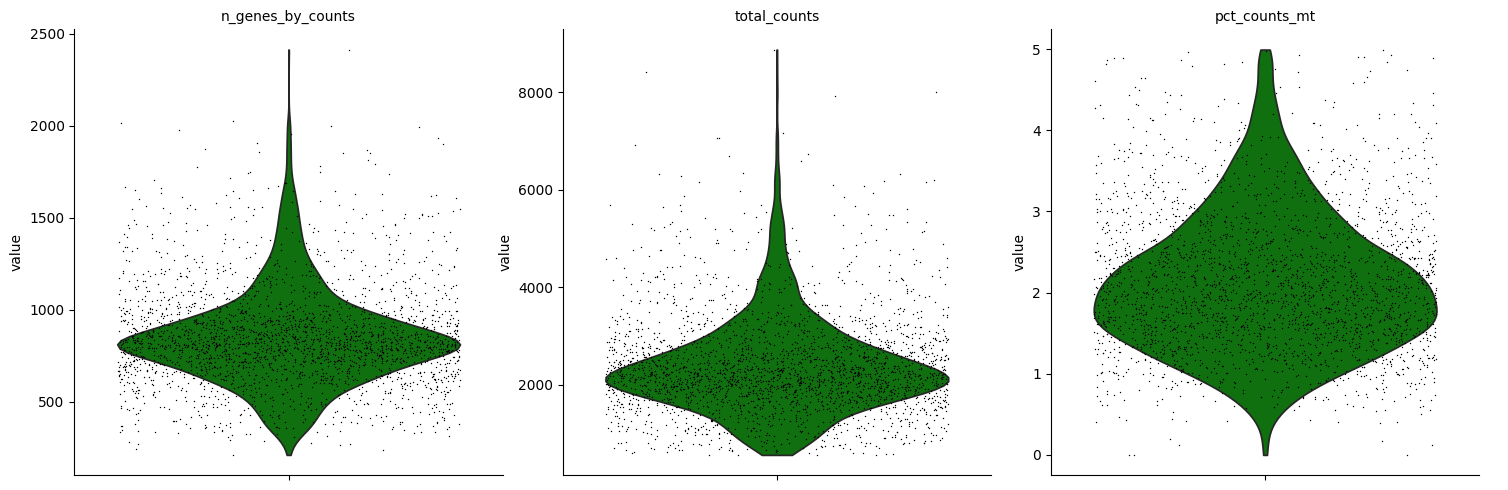

In [11]:
sc.pl.violin(
    pbmc_data,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    color = 'green'
)

## Count Normalisation and Feature Selection 
Preparing data for clustering and dimensionality reduction.
This process includes:
+ Normalization
+ Log transforming
+ Selecting HVGs (layer="counts" Uses raw count data (not normalized / not log-transformed). This is important because HVG detection assumes raw distributions)
+ Scaling and Regression

In [12]:
pbmc_data = pr.preprocess(pbmc_data)

/Users/lola/Desktop/Agentic_Thesis/preprocessing.py:29: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
  adata.layers["scaled"] = adata.X.toarray()


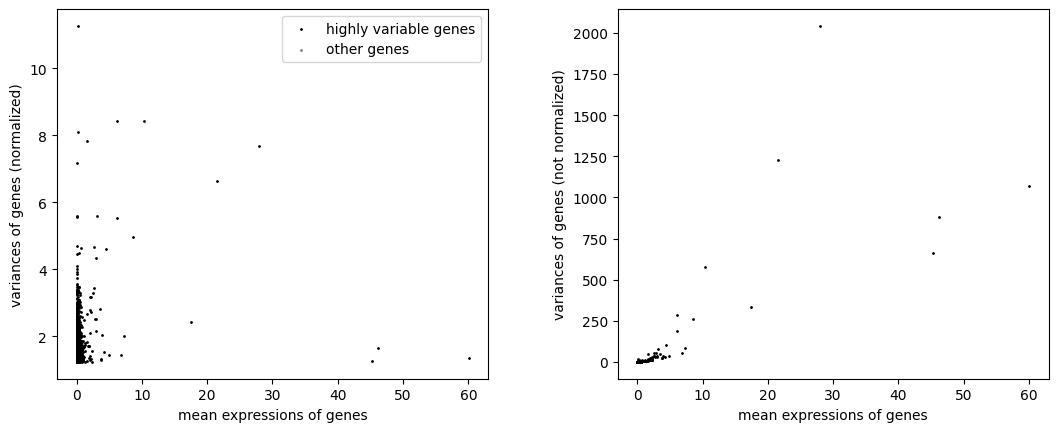

In [13]:
sc.pl.highly_variable_genes(pbmc_data)

In [75]:
pbmc_data.var["highly_variable"]

index
ISG15      True
CPSF3L     True
MRPL20     True
ATAD3C     True
C1orf86    True
           ... 
SUMO3      True
SLC19A1    True
S100B      True
MT-CO2     True
MT-ND6     True
Name: highly_variable, Length: 2000, dtype: bool

## PRINCIPAL COMPONENT ANALYSIS

PCA compresses gene expression into “axes of variation”

In [14]:
pbmc_data.layers.keys()

KeysView(Layers with keys: counts, scaled)

In [15]:
sc.pp.pca(pbmc_data, layer="scaled", svd_solver="arpack") 
#n_comps by default takes thousands of genes compresses them into 50 new features

In [16]:
pbmc_data.obsm["X_pca"].shape
# pbmc_data.obsm["X_pca"]; PCA coordinates (cells × PCs)
# pbmc_data.varm["PCs"];  gene loadings
# pbmc_data.uns["pca"]   metadata (variance, etc.)

(2638, 50)

### PCA Elbow Plot (Variance Ratio Plot)

This visualization shows the proportion of total variance explained by each of the first 20 principal components (PCs). It helps identify how much biological variation is captured by the PCA representation and assists in selecting an appropriate number of PCs for downstream analyses such as neighborhood graph construction, UMAP visualization, and clustering. The point at which the explained variance begins to level off (the "elbow") is commonly used as a guideline for determining the optimal number of PCs to retain.

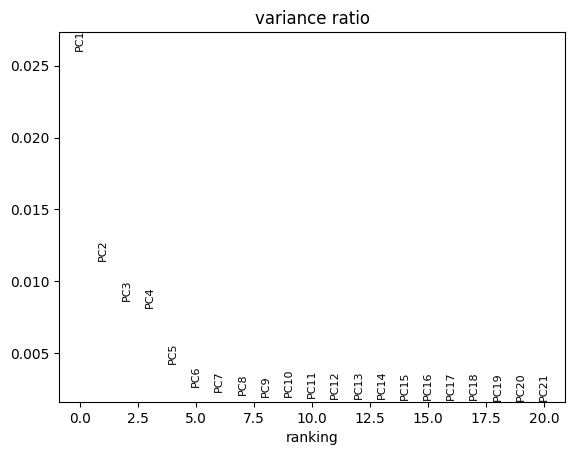

In [18]:
sc.pl.pca_variance_ratio(pbmc_data, n_pcs=20)

## Building cell similarity graph and Clustering

+ Uses the first 20 PCs
+ Computes which cells are similar
+ Builds a graph of cell–cell relationships

This graph is them used for UMAP and clustering (Leiden/Louvain)